In [ ]:
###############
#USE WITH SYNOPTIC DATASETS (Mesowest Sites)
#USE FOR Indexing MAX, MIN, AVG TEMPS#

#1) Download dataset from Synoptic API (English Units, UTC: Temp., wind speed, wind dir, wind chill, heat index, dew point)
#2) Convert the .csv to .xlsx ; change file name, sheet name, & variable names to match index below
#3) Upload excel workbook and ensure file_name is identical
#4) Change specific dates (easy with chatgpt)
#5) Run code and use next code block to plot
#6) Run again for each Site and for each different date
###############

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel file into a pandas DataFrame
file_name = 'E3114.2025-05-01.xlsx'
sheet_name = 'Sheet1'
df = pd.read_excel(file_name, sheet_name=sheet_name)

# Convert the 'Valid' column to datetime and set it as index
df['Valid'] = pd.to_datetime(df['Valid'])
df.set_index('Valid', inplace=True)

# Resample the data at 60-minute intervals to get mean, max, and min temperatures
resampled_df = df.resample('60T').agg({
    'Air T': ['mean', 'max', 'min'],
    'Wind SPD': 'mean',
    'Wind DIR': 'mean',
 #   'Wind GST': 'max',
    'Dewpoint': ['mean', 'max', 'min']  # Add Dewpoint
})
resampled_df.columns = ['_'.join(col).strip() for col in resampled_df.columns.values]
resampled_df.index = resampled_df.index.tz_localize(None)

# Calculate overall averages
overall_averages = resampled_df.mean()

# Create a list to store data for each specific date and time
data_list = []

# Define specific dates and times
specific_dates = [
'2018-07-10', '2018-07-11', '2018-07-12', '2018-07-13', '2018-07-14',
'2019-07-10', '2019-07-11', '2019-07-12', '2019-07-13', '2019-07-14',
'2020-07-10', '2020-07-11', '2020-07-12', '2020-07-13', '2020-07-14',
'2021-07-10', '2021-07-11', '2021-07-12', '2021-07-13', '2021-07-14',
'2022-07-10', '2022-07-11', '2022-07-12', '2022-07-13', '2022-07-14',
'2023-07-10', '2023-07-11', '2023-07-12', '2023-07-13', '2023-07-14',
'2024-07-10', '2024-07-11', '2024-07-12', '2024-07-13', '2024-07-14'


]

specific_times = ['00:00:00', '01:00:00', '02:00:00', '03:00:00', '04:00:00', '05:00:00', '06:00:00',
                  '07:00:00', '08:00:00', '09:00:00', '10:00:00', '11:00:00', '12:00:00', '13:00:00',
                  '14:00:00', '15:00:00', '16:00:00', '17:00:00', '18:00:00', '19:00:00', '20:00:00',
                  '21:00:00', '22:00:00', '23:00:00']

# Calculate hourly averages for each specific date and time
for date in specific_dates:
    for specific_time in specific_times:
        specific_data = resampled_df.loc[date].between_time(specific_time, specific_time)

        # Calculate the mean values for each variable
        mean_temperature = specific_data['Air T_mean'].mean()
        mean_wind_speed = specific_data['Wind SPD_mean'].mean()
        mean_wind_direction = specific_data['Wind DIR_mean'].mean()
        mean_dewpoint = specific_data['Dewpoint_mean'].mean()  # Add mean Dewpoint

        # Calculate the max and min values for the temperature and dewpoint
        max_temperature = specific_data['Air T_max'].max()
        min_temperature = specific_data['Air T_min'].min()
     #   max_wind_gust = specific_data['Wind GST_max'].max()
        max_dewpoint = specific_data['Dewpoint_max'].max()  # Add max Dewpoint
        min_dewpoint = specific_data['Dewpoint_min'].min()  # Add min Dewpoint

        # Append data to the list
        data_list.append({'Date': date,
                          'Time': specific_time,
                          'Mean Temperature': mean_temperature,
                          'Max Temperature': max_temperature,
                          'Min Temperature': min_temperature,
                          'Wind Speed': mean_wind_speed,
                          'Wind Direction': mean_wind_direction,
        #                  'Wind Gust': max_wind_gust,
                          'Mean Dewpoint': mean_dewpoint,  # Add mean Dewpoint
                          'Max Dewpoint': max_dewpoint,  # Add max Dewpoint
                          'Min Dewpoint': min_dewpoint})  # Add min Dewpoint

# Convert the list of dictionaries to a DataFrame
results_df = pd.DataFrame(data_list)

# Add overall averages to the results DataFrame
overall_averages_df = pd.DataFrame(overall_averages).transpose()
overall_averages_df['Date'] = 'Overall'
results_df = pd.concat([results_df, overall_averages_df], ignore_index=True)

# Save results to Excel (optional)
results_file_name = 'hourly_averages_with_dates.xlsx'
results_df.to_excel(results_file_name, index=False)

# Display results DataFrame
print(results_df)

# Read the Excel file
data = pd.read_excel('hourly_averages_with_dates.xlsx')

# Convert 'Time' column to datetime type
data['Time'] = pd.to_datetime(data['Time'])

# Extract hour from the 'Time' column
data['Hour'] = data['Time'].dt.hour

# Group by hour and calculate average values
hourly_stats = data.groupby('Hour').agg({
    'Mean Temperature': 'mean',
    'Max Temperature': 'max',
    'Min Temperature': 'min',
    'Wind Speed': 'mean',
    'Wind Direction': 'mean',
  #  'Wind Gust': 'max',
    'Mean Dewpoint': 'mean',  # Add mean Dewpoint
    'Max Dewpoint': 'max',  # Add max Dewpoint
    'Min Dewpoint': 'min'  # Add min Dewpoint
    }).reset_index()

# Print the results
print(hourly_stats)

/tmp/ipython-input-2-2921573906.py:27: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  resampled_df = df.resample('60T').agg({


           Date      Time  Mean Temperature  Max Temperature  Min Temperature  \
0    2018-07-10  00:00:00           88.2575            89.01            87.01   
1    2018-07-10  01:00:00           85.4950            86.00            84.99   
2    2018-07-10  02:00:00           83.9950            84.99            82.99   
3    2018-07-10  03:00:00           82.7425            82.99            82.00   
4    2018-07-10  04:00:00           82.0000            82.00            82.00   
..          ...       ...               ...              ...              ...   
836  2024-07-14  20:00:00               NaN              NaN              NaN   
837  2024-07-14  21:00:00               NaN              NaN              NaN   
838  2024-07-14  22:00:00               NaN              NaN              NaN   
839  2024-07-14  23:00:00               NaN              NaN              NaN   
840     Overall       NaN               NaN              NaN              NaN   

     Wind Speed  Wind Direc

/tmp/ipython-input-2-2921573906.py:111: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Time'] = pd.to_datetime(data['Time'])


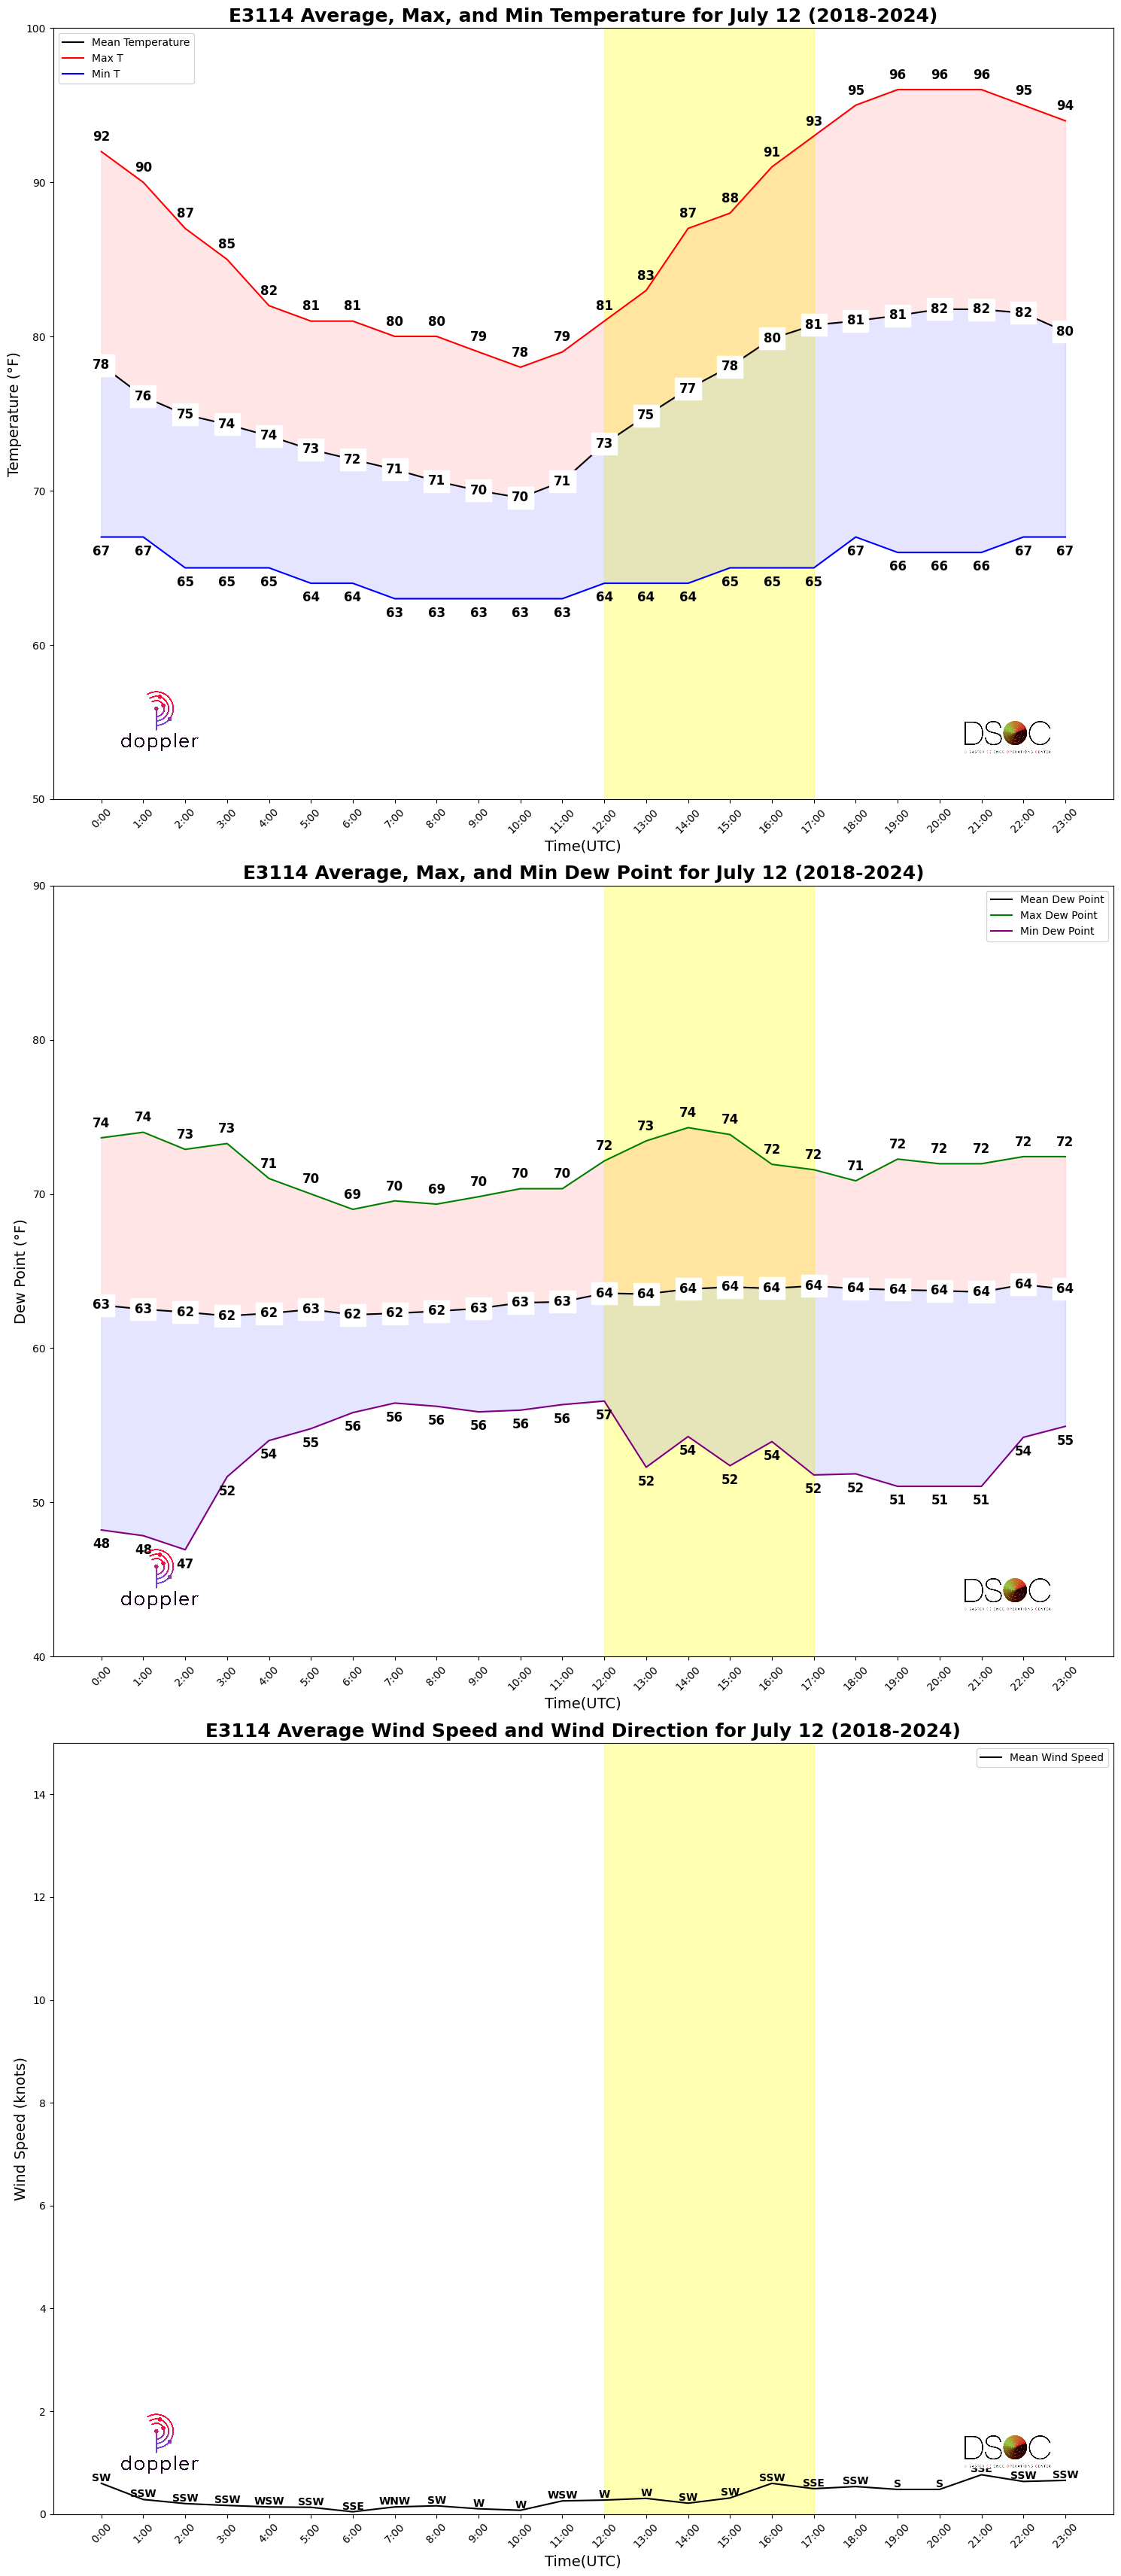

In [ ]:
###############
#USE WITH SYNOPTIC DATASETS
#USE FOR PLOTTING MAX, MIN, AVG TEMPS#
#1) Uploaded images (if needed)
#2) Change each plot title to reflect data
#3) Change ylim to fit data ; change axvspan for race window
###############

import matplotlib.pyplot as plt
import matplotlib.image as image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import math

# Define the image paths
file1 = "/content/DopplerLogo_Primary_noEOC.png"  # Replace with your image path
file2 = "/content/DSOC logo.PNG"  # Replace with your second image path
logo1 = image.imread(file1)
logo2 = image.imread(file2)

# Define the degrees_to_cardinal function
def degrees_to_cardinal(degrees):
    if math.isnan(degrees):
        return None
    directions = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE', 'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
    idx = int((degrees / 22.5) + 0.5) % 16
    return directions[idx]

# Create figure
fig = plt.figure(figsize=(15, 45))  # Increased figure height to accommodate new plot

# Plot Max, min, mean Temperature
ax1 = fig.add_subplot(4, 1, 1)
ax1.plot(hourly_stats['Hour'], hourly_stats['Mean Temperature'], label='Mean Temperature', color='black')
ax1.plot(hourly_stats['Hour'], hourly_stats['Max Temperature'], label='Max T', color='red')
ax1.plot(hourly_stats['Hour'], hourly_stats['Min Temperature'], label='Min T', color='blue')
ax1.set_title('E3114 Average, Max, and Min Temperature for July 12 (2018-2024)', fontsize=18, fontweight='bold')
ax1.set_xlabel('Time(UTC)', fontsize=14)
ax1.set_ylabel('Temperature (°F)', fontsize=14)
ax1.set_ylim(50, 100)  # Set the y-axis limits
ax1.axvspan(12, 17, color='yellow', alpha=0.3)  # Add yellow 'race window' box
#ax1.text(14, 95, 'Race Window', fontsize=12, fontweight='bold', ha='center', va='center')
ax1.legend()
ax1.set_xticks(hourly_stats['Hour'])
ax1.set_xticklabels([f"{int(hour)}:00" for hour in hourly_stats['Hour']], rotation=45)

# Shade the area between Mean Temperature and Max Temperature
ax1.fill_between(hourly_stats['Hour'], hourly_stats['Mean Temperature'], hourly_stats['Max Temperature'], color='red', alpha=0.1)

# Shade the area between Mean Temperature and Min Temperature
ax1.fill_between(hourly_stats['Hour'], hourly_stats['Mean Temperature'], hourly_stats['Min Temperature'], color='blue', alpha=0.1)

# Add data labels for Mean T
for hour, temp in zip(hourly_stats['Hour'], hourly_stats['Mean Temperature']):
    ax1.text(hour, temp, f'{round(temp):.0f}', ha='center', va='center', fontsize=12, fontweight='bold', backgroundcolor='white')

# Add data labels for Max T
for hour, temp in zip(hourly_stats['Hour'], hourly_stats['Max Temperature']):
    ax1.text(hour, temp + .5, f'{round(temp):.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add data labels for Min T
for hour, temp in zip(hourly_stats['Hour'], hourly_stats['Min Temperature']):
    ax1.text(hour, temp - .5, f'{round(temp):.0f}', ha='center', va='top', fontsize=12, fontweight='bold')

# Add first image to the first plot
imagebox1 = OffsetImage(logo1, zoom=0.04)
ab1 = AnnotationBbox(imagebox1, (0.1, 0.1), frameon=False, xycoords='axes fraction')
ax1.add_artist(ab1)

# Add second image to the first plot
imagebox2 = OffsetImage(logo2, zoom=0.12)
ab2 = AnnotationBbox(imagebox2, (0.9, 0.08), frameon=False, xycoords='axes fraction')
ax1.add_artist(ab2)

# Plot Max, min, mean Dew Point (Second Plot)
ax2 = fig.add_subplot(4, 1, 2)
ax2.plot(hourly_stats['Hour'], hourly_stats['Mean Dewpoint'], label='Mean Dew Point', color='black')
ax2.plot(hourly_stats['Hour'], hourly_stats['Max Dewpoint'], label='Max Dew Point', color='green')
ax2.plot(hourly_stats['Hour'], hourly_stats['Min Dewpoint'], label='Min Dew Point', color='purple')
ax2.set_title('E3114 Average, Max, and Min Dew Point for July 12 (2018-2024)', fontsize=18, fontweight='bold')
ax2.set_xlabel('Time(UTC)', fontsize=14)
ax2.set_ylabel('Dew Point (°F)', fontsize=14)
ax2.set_ylim(40, 90)  # Adjust y-axis limits as needed
ax2.axvspan(12, 17, color='yellow', alpha=0.3)  # Add yellow 'race window' box
#ax2.text(14, 85, 'Race Window', fontsize=12, fontweight='bold', ha='center', va='center')
ax2.legend()
ax2.set_xticks(hourly_stats['Hour'])
ax2.set_xticklabels([f"{int(hour)}:00" for hour in hourly_stats['Hour']], rotation=45)

# Shade the area between Mean Dew Point and Max Dew Point
ax2.fill_between(hourly_stats['Hour'], hourly_stats['Mean Dewpoint'], hourly_stats['Max Dewpoint'], color='red', alpha=0.1)

# Shade the area between Mean Dew Point and Min Dew Point
ax2.fill_between(hourly_stats['Hour'], hourly_stats['Mean Dewpoint'], hourly_stats['Min Dewpoint'], color='blue', alpha=0.1)

# Add data labels for Mean Dew Point
for hour, dp in zip(hourly_stats['Hour'], hourly_stats['Mean Dewpoint']):
    ax2.text(hour, dp, f'{round(dp):.0f}', ha='center', va='center', fontsize=12, fontweight='bold', backgroundcolor='white')

# Add data labels for Max Dew Point
for hour, dp in zip(hourly_stats['Hour'], hourly_stats['Max Dewpoint']):
    ax2.text(hour, dp + 0.5, f'{round(dp):.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add data labels for Min Dew Point
for hour, dp in zip(hourly_stats['Hour'], hourly_stats['Min Dewpoint']):
    ax2.text(hour, dp - 0.5, f'{round(dp):.0f}', ha='center', va='top', fontsize=12, fontweight='bold')

# Add logos to the second plot
imagebox1 = OffsetImage(logo1, zoom=0.04)
ab1 = AnnotationBbox(imagebox1, (0.1, 0.1), frameon=False, xycoords='axes fraction')
ax2.add_artist(ab1)

imagebox2 = OffsetImage(logo2, zoom=0.12)
ab2 = AnnotationBbox(imagebox2, (0.9, 0.08), frameon=False, xycoords='axes fraction')
ax2.add_artist(ab2)

# Plot Max, min, mean Wind Speed (Third Plot)
ax3 = fig.add_subplot(4, 1, 3)
ax3.plot(hourly_stats['Hour'], hourly_stats['Wind Speed'], label='Mean Wind Speed', color='black')
#ax3.plot(hourly_stats['Hour'], hourly_stats['Wind Gust'], label='Max Wind Gust', color='red')
ax3.set_title('E3114 Average Wind Speed and Wind Direction for July 12 (2018-2024)', fontsize=18, fontweight='bold')
ax3.set_xlabel('Time(UTC)', fontsize=14)
ax3.set_ylabel('Wind Speed (knots)', fontsize=14)
ax3.set_ylim(0, 15)  # Set the y-axis limits
ax3.axvspan(12, 17, color='yellow', alpha=0.3)  # Add yellow 'race window' box
#ax3.text(14, 5, 'Race Window', fontsize=12, fontweight='bold', ha='center', va='center')
ax3.legend()
ax3.set_xticks(hourly_stats['Hour'])
ax3.set_xticklabels([f"{int(hour)}:00" for hour in hourly_stats['Hour']], rotation=45)

# Shade the area between Mean Wind Speed and Max Wind Speed
#ax3.fill_between(hourly_stats['Hour'], hourly_stats['Wind Speed'], hourly_stats['Wind Gust'], color='red', alpha=0.1)

# Add data labels for Wind Gusts
#for hour, gust in zip(hourly_stats['Hour'], hourly_stats['Wind Gust']):
#    ax3.text(hour, gust + 1, f'{round(gust):.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

# Plot wind direction as markers on the wind speed plot (commented out)
wind_directions = hourly_stats['Wind Direction']
wind_speeds = hourly_stats['Wind Speed']
for hour, wind_dir, wind_speed in zip(hourly_stats['Hour'], wind_directions, hourly_stats['Wind Speed']):
    cardinal_direction = degrees_to_cardinal(wind_dir)
    ax3.text(hour, wind_speed, cardinal_direction, ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

# Add logos to the third plot (commented out)
imagebox1 = OffsetImage(logo1, zoom=0.04)
ab1 = AnnotationBbox(imagebox1, (0.1, 0.09), frameon=False, xycoords='axes fraction')
ax3.add_artist(ab1)

imagebox2 = OffsetImage(logo2, zoom=0.12)
ab2 = AnnotationBbox(imagebox2, (0.9, 0.08), frameon=False, xycoords='axes fraction')
ax3.add_artist(ab2)

plt.tight_layout()
plt.show()